<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB49 · El tiempo: integradores, estabilidad y rendimiento

**Parte 6 · Simulación de bípedos a fondo — Bloque A: MuJoCo por dentro — Lección 5 (y última del bloque)**

> Un simulador no ve el tiempo como tú: no fluye, **salta**. Cada `mj_step` avanza 0,002 segundos de golpe, y entre salto y salto no existe nada. Cómo se da ese salto (el **integrador**) y de qué tamaño (el **pasito**) decide si la simulación es precisa, si es estable... o si **explota**.

En el NB07 lo vimos con la pelota (con un pasito grande, caía 0,725 m en vez de 0,75) y en el NB45, con la energía de la caja que bajaba un 0,4 % sin motivo. Hoy lo estudiamos a fondo, porque es una de las preguntas favoritas en las entrevistas de simulación:

- "¿Qué integradores tiene MuJoCo? ¿Cuál usarías para un robot con patas y por qué?"
- "Tu simulación explota. ¿Qué miras primero?"
- "¿Cómo elegirías el pasito de tiempo?"
- "Tu entrenamiento va lento. ¿Cómo encuentras el cuello de botella? ¿Cómo lo paralelizas?"

Y cerramos el Bloque A con el **rendimiento**: medir, perfilar y simular en paralelo. En el hilo de Python, tres herramientas de nivel profesional: **decoradores**, **gestores de contexto** (`with`) y **multiproceso**.


In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"

import time
import mujoco
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True, linewidth=120)

## 1 · Integrar: avanzar a saltitos

### Explícito y semiimplícito, a mano

Recuerda el NB45: MuJoCo, por defecto, avanza con **Euler semiimplícito**: primero actualiza la velocidad con la aceleración, y después la posición con la velocidad **nueva**. La pelota del NB07 usaba **Euler explícito**: la posición con la velocidad **vieja**. Dije que esa pequeña diferencia hace que el semiimplícito sea "mucho más estable". Ahora vamos a **verlo**, programando los dos a mano en un **péndulo simple** (una masa en la punta de un hilo de longitud L), cuya aceleración angular es (NB37):

```
   θ̈  =  −(g / L) · sen(θ)
```

Y su energía (por unidad de masa): cinética ½·(L·θ̇)² más potencial g·L·(1 − cos θ). En la física de verdad, esa energía **no cambia nunca**.


In [2]:
G, L = 9.81, 1.0

def aceleracion(theta: float) -> float:
    return -(G / L) * np.sin(theta)

def energia(theta: float, omega: float) -> float:
    return 0.5 * (L * omega) ** 2 + G * L * (1 - np.cos(theta))

def pendulo_a_mano(semiimplicito: bool, dt: float = 0.01, segundos: float = 20.0) -> np.ndarray:
    theta, omega = 1.0, 0.0                     # soltado desde 1 rad (57°), parado
    energias = []
    for paso in range(int(round(segundos / dt))):
        a = aceleracion(theta)
        if semiimplicito:
            omega = omega + a * dt              # primero la velocidad...
            theta = theta + omega * dt          # ...y la posición con la velocidad NUEVA
        else:
            theta, omega = theta + omega * dt, omega + a * dt   # las dos con los valores VIEJOS
        energias.append(energia(theta, omega))
    return np.array(energias)

explicito = pendulo_a_mano(semiimplicito=False)
semi = pendulo_a_mano(semiimplicito=True)
print(f"energía inicial:              {energia(1.0, 0.0):.4f} J/kg")
print(f"explícito, a los 20 s:        {explicito[-1]:.4f} J/kg")
print(f"semiimplícito, a los 20 s:    {semi[-1]:.4f} J/kg")

energía inicial:              4.5096 J/kg
explícito, a los 20 s:        16.5050 J/kg
semiimplícito, a los 20 s:    4.5761 J/kg


(En la línea del explícito, `theta, omega = theta + omega * dt, omega + a * dt` calcula **los dos** lados derechos con los valores de antes, y **después** asigna: es la asignación múltiple de Python, NB21. Si lo escribiéramos en dos líneas, la segunda ya usaría el `theta` nuevo.)


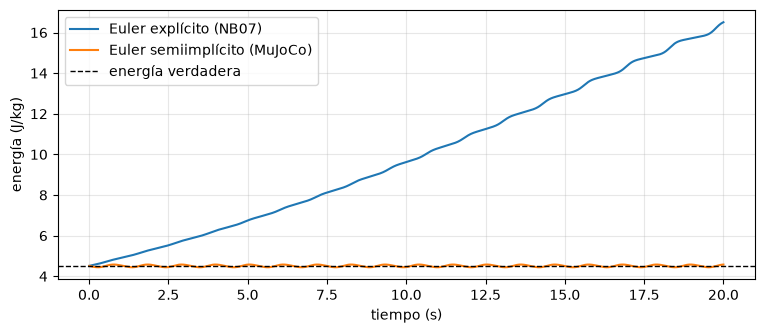

In [3]:
t = np.arange(1, len(semi) + 1) * 0.01
plt.figure(figsize=(9, 3.5))
plt.plot(t, explicito, label="Euler explícito (NB07)")
plt.plot(t, semi, label="Euler semiimplícito (MuJoCo)")
plt.axhline(energia(1.0, 0.0), color="k", ls="--", lw=1, label="energía verdadera")
plt.xlabel("tiempo (s)")
plt.ylabel("energía (J/kg)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Qué acabamos de ver

Los dos métodos hacen **las mismas cuentas**, solo que en distinto orden, y el resultado es completamente distinto:

- **Euler explícito**: la energía empieza en 4,51 J/kg y a los 20 segundos vale **16,5**: más del **triple**. El péndulo, que debería subir siempre hasta la misma altura, sube cada vez un poco más, hasta dar vueltas completas. Nadie le ha dado energía: la ha **fabricado el método numérico**. Si lo dejaras correr más, seguiría creciendo sin límite.
- **Euler semiimplícito**: la energía se queda **pegada** a la verdadera (4,58 a los 20 s). No es exacta (sube y baja un poquito alrededor del valor verdadero, lo verás si haces zoom en la gráfica), pero **no se escapa nunca**.

¿Por qué? Una forma intuitiva de verlo: en el explícito, el péndulo avanza con la velocidad **de antes** de que la gravedad la frene. Cuando sube, frena "tarde", y llega un poco más alto de lo que debería. Cada vaivén, un poquito más. En el semiimplícito, la posición usa la velocidad **ya frenada**, y los errores de la subida y de la bajada se **compensan** en lugar de acumularse.

(Para los curiosos: los métodos que tienen esta propiedad de no "inventar" ni "perder" energía a la larga se llaman **simplécticos**. El Euler semiimplícito lo es; el explícito, no. Es una palabra que impresiona en una entrevista, pero la idea es solo esta: los errores no se acumulan en la energía.)

**Moraleja para un robot**: un robot que gana energía de la nada salta, vibra y acaba explotando. Por eso **ningún** simulador serio usa Euler explícito.


## 2 · Los integradores de MuJoCo

MuJoCo tiene cinco integradores, que se eligen con `<option integrator="...">`:

| Integrador | Qué hace | Coste por paso |
|---|---|---|
| **`Euler`** (por defecto) | Euler semiimplícito... con un truco: trata la **amortiguación de las articulaciones** (`damping`) de forma implícita | 1 |
| **`implicitfast`** | además trata de forma implícita las fuerzas que dependen de la **velocidad**: amortiguadores, los `kv` de los motores de posición (NB40)... | ≈ 1 |
| **`implicit`** | como el anterior, más completo (incluye efectos de los giros), más caro | algo más |
| **`RK4`** | Runge-Kutta de orden 4: evalúa la dinámica **4 veces** por paso y combina los resultados | ≈ 4 |
| `discrete` | uno especial para ciertos usos de control; no lo veremos | |

"Implícito" significa que, para calcular el estado **siguiente**, se usan las fuerzas **del estado siguiente** (que aún no se conocen), lo que obliga a resolver una pequeña ecuación en cada paso. A cambio, es **estable** con fuerzas muy rígidas que harían explotar a un método explícito (sección 4).

Primera comparación: un péndulo de verdad en MuJoCo (una varilla de 1 m y 1 kg), soltado desde 1,5 rad, durante 10 segundos, con dos pasitos. ¿Cuánta energía gana o pierde con cada integrador?


In [4]:
PENDULO = '''
<mujoco>
  <compiler angle="radian"/>
  <option timestep="{dt}" integrator="{integrador}"><flag energy="enable"/></option>
  <worldbody>
    <body pos="0 0 2">
      <joint type="hinge" axis="0 1 0"/>
      <geom type="capsule" fromto="0 0 0  0 0 -1" size="0.02" mass="1"/>
    </body>
  </worldbody>
</mujoco>
'''

def deriva_de_energia(integrador: str, dt: float, segundos: float = 10.0) -> float:
    m = mujoco.MjModel.from_xml_string(PENDULO.format(dt=dt, integrador=integrador))
    d = mujoco.MjData(m)
    d.qpos[0] = 1.5
    mujoco.mj_forward(m, d)
    inicial = d.energy.sum()
    for paso in range(int(round(segundos / dt))):
        mujoco.mj_step(m, d)
    return d.energy.sum() - inicial

print(f"{'integrador':>13} | {'dt = 0,01':>11} | {'dt = 0,002':>11}")
for integrador in ["Euler", "implicit", "implicitfast", "RK4"]:
    print(f"{integrador:>13} | {deriva_de_energia(integrador, 0.01):+11.2e} | {deriva_de_energia(integrador, 0.002):+11.2e}")

   integrador |   dt = 0,01 |  dt = 0,002
        Euler |   -4.14e-02 |   -7.79e-03
     implicit |   -4.14e-02 |   -7.79e-03
 implicitfast |   -4.14e-02 |   -7.79e-03
          RK4 |   +6.44e-06 |   +6.27e-08


### Leyendo la tabla

(Los números están en **notación científica**: `-4.14e-02` significa −4,14 × 10⁻², es decir, −0,0414. El `e-02` dice "mueve la coma dos sitios a la izquierda".)

1. **Euler, implicit e implicitfast dan exactamente lo mismo.** Tiene sentido: los tres solo se diferencian en cómo tratan las fuerzas que dependen de la **velocidad** (amortiguadores, `kv`), y este péndulo **no tiene ninguna**. Sin esas fuerzas, los tres son el mismo Euler semiimplícito. La diferencia aparecerá en la sección 4.
2. **Pierden un poquito de energía**: 0,041 J de unos 4,6 J de energía inicial (la varilla, con su centro a 0,5 m del eje, soltada desde 1,5 rad: 1 · 9,81 · 0,5 · (1 − cos 1,5) ≈ 4,56 J) con un pasito de 0,01, menos del 1 %. Con el pasito 5 veces más pequeño (0,002, el de MuJoCo por defecto), pierden **unas 5 veces menos** (0,0078). Esto ya nos da una pista de la sección siguiente: el error es **proporcional** al pasito.
3. **RK4 es muchísimo más preciso**: con dt = 0,01, un error de 6 millonésimas, **6.000 veces menor** que Euler. Con dt = 0,002, de 6 cienmillonésimas.

¿Entonces por qué no usar siempre RK4? Por tres motivos que veremos hoy: cuesta **4 veces más** por paso; su precisión brilla en movimientos **suaves** (como este péndulo), pero los contactos son **bruscos** (un pie que toca el suelo cambia de golpe), y ahí la ventaja se esfuma; y, como verás en la sección 5, con un robot de verdad puede ser **menos** estable que `implicitfast`.


## 3 · El orden de un integrador

### Cómo baja el error con el pasito

Una propiedad clave de cada integrador es su **orden**: cómo baja el error cuando haces el pasito más pequeño. Si un método es de **orden p**, dividir el pasito entre 2 divide el error entre **2ᵖ**:

- **Euler** es de orden 1: pasito a la mitad → error a la mitad.
- **RK4** es de orden 4: pasito a la mitad → error **16 veces** menor.

Comprobémoslo. Necesitamos la respuesta "verdadera", que no tenemos... pero podemos fabricarla: RK4 con un pasito minúsculo (10⁻⁵ s) es tan preciso que nos vale como referencia. Medimos el ángulo del péndulo a los 2 segundos:


In [5]:
def angulo_final(integrador: str, dt: float, segundos: float = 2.0) -> float:
    m = mujoco.MjModel.from_xml_string(PENDULO.format(dt=dt, integrador=integrador))
    d = mujoco.MjData(m)
    d.qpos[0] = 1.5
    for paso in range(int(round(segundos / dt))):
        mujoco.mj_step(m, d)
    return d.qpos[0]

referencia = angulo_final("RK4", 1e-5)
pasitos = [0.02, 0.01, 0.005, 0.0025]
errores = {integrador: [abs(angulo_final(integrador, dt) - referencia) for dt in pasitos]
           for integrador in ["Euler", "RK4"]}
for integrador, lista in errores.items():
    print(integrador, ["%.2e" % e for e in lista],
          " cocientes:", [float(round(lista[i] / lista[i + 1], 1)) for i in range(len(lista) - 1)])

Euler ['1.21e-02', '6.05e-03', '3.02e-03', '1.51e-03']  cocientes: [2.0, 2.0, 2.0]
RK4 ['1.46e-07', '1.46e-08', '1.09e-09', '7.34e-11']  cocientes: [10.0, 13.5, 14.8]


(La línea de `errores` es una **comprensión de diccionario** con una comprensión de lista dentro, NB21: para cada integrador, la lista de errores con cada pasito.)

Dibujado en escala **log-log** (los dos ejes logarítmicos), un método de orden p sale como una **recta de pendiente p**:


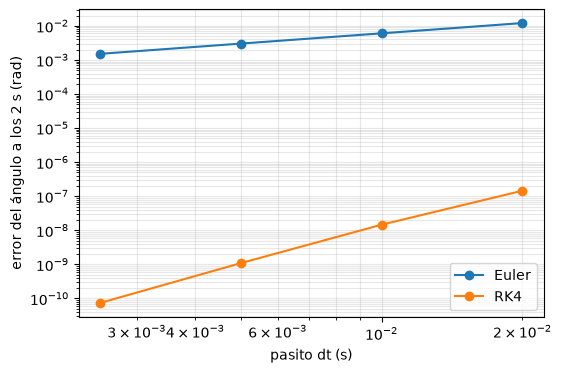

In [6]:
plt.figure(figsize=(6, 4))
for integrador, lista in errores.items():
    plt.loglog(pasitos, lista, "o-", label=integrador)
plt.xlabel("pasito dt (s)")
plt.ylabel("error del ángulo a los 2 s (rad)")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

### Leyendo los cocientes

- **Euler**: cada vez que dividimos el pasito entre 2, el error se divide entre **2,0**. Exactamente lo que predice el orden 1. En la gráfica, una recta que baja **una** década (×10) por cada década de pasito: pendiente 1.
- **RK4**: los cocientes son 10; 13,5; 14,8... acercándose a **16** = 2⁴. No llegan del todo porque la teoría del orden habla de pasitos "suficientemente pequeños", y con 0,02 s aún no lo somos tanto; según el pasito se encoge, el cociente se acerca a 16. En la gráfica, una recta mucho más **empinada**: pendiente casi 4.

¿Por qué una recta? Si error ≈ C · dtᵖ, tomando logaritmos (NB28): log(error) ≈ log(C) + p · log(dt). Eso es la ecuación de una recta en la que **p es la pendiente**. Es el mismo truco de siempre: los logaritmos convierten potencias en rectas, y las rectas se leen a simple vista.

Esta gráfica es una herramienta **profesional**: si programas un integrador (o una pieza nueva de un simulador) y quieres comprobar que está bien hecho, mides su orden así. Si la pendiente no es la que debería, hay un error en el código. Se llama **estudio de convergencia**.

Observa también la escala: con dt = 0,0025, Euler se equivoca en 1,5 milésimas de radián y RK4 en **0,00000000007**. Para un péndulo que se mueve suave, RK4 gana por goleada.


## 4 · Estabilidad: cuándo explota una simulación

### Rigidez

Precisión y estabilidad son cosas distintas. Una simulación **imprecisa** da números algo equivocados; una **inestable** da números que **crecen sin límite** hasta el infinito: **explota**. Y lo que hace explotar una simulación es la **rigidez** (*stiffness*): fuerzas que cambian **muy deprisa**, como un muelle muy duro o un amortiguador muy fuerte.

La regla, que dedujiste en el NB39b (apartado 7), para un muelle que oscilaría con frecuencia ω (en rad/s, ω = √(rigidez / inercia)): los métodos explícitos (y el Euler semiimplícito) son estables solo si

```
   pasito · ω  <  2
```

Es decir: cada oscilación tiene que durar, como poco, unos cuantos pasitos. Si el muelle oscila más deprisa de lo que el pasito puede "ver", la simulación explota.

Pongámoslo a prueba con una varilla de 40 cm colgando de un **muelle de torsión** (`stiffness` en la articulación). Su inercia es m·L²/3 ≈ 0,053 kg·m², así que con rigidez k, ω = √(k / 0,053). Con un pasito de 0,01 s, el límite es ω < 200 rad/s, o sea, k < unos 2.100:


In [7]:
MUELLE = '''
<mujoco>
  <compiler angle="radian"/>
  <option timestep="{dt}" integrator="{integrador}"/>
  <worldbody>
    <body pos="0 0 2">
      <joint name="j" type="hinge" axis="0 1 0" stiffness="{k}"/>
      <geom type="capsule" fromto="0 0 0  0 0 -0.4" size="0.02" mass="1"/>
    </body>
  </worldbody>
  <actuator>
    <position joint="j" kp="{kp}" kv="{kv}"/>
  </actuator>
</mujoco>
'''

def probar(integrador: str, dt: float = 0.01, k: float = 0, kp: float = 0, kv: float = 0,
           segundos: float = 2.0) -> tuple[float, int]:
    m = mujoco.MjModel.from_xml_string(MUELLE.format(dt=dt, integrador=integrador, k=k, kp=kp, kv=kv))
    d = mujoco.MjData(m)
    d.qpos[0] = 0.5
    mayor = 0.0
    for paso in range(int(round(segundos / dt))):           # ¡un número FIJO de pasos! (ahora verás por qué)
        mujoco.mj_step(m, d)
        mayor = max(mayor, abs(d.qpos[0]))
    return mayor, d.warning[mujoco.mjtWarning.mjWARN_BADQACC].number

inercia = 1.0 * 0.4**2 / 3
for k in [100, 1000, 5000]:
    omega = np.sqrt(k / inercia)
    mayor, avisos = probar("Euler", k=k)
    print(f"k = {k:5d}  →  ω = {omega:5.0f} rad/s,  pasito·ω = {0.01 * omega:.2f}  →  "
          f"ángulo máximo {mayor:12.2f} rad,  avisos: {avisos}")

k =   100  →  ω =    43 rad/s,  pasito·ω = 0.43  →  ángulo máximo         0.51 rad,  avisos: 0
k =  1000  →  ω =   137 rad/s,  pasito·ω = 1.37  →  ángulo máximo         0.68 rad,  avisos: 0
k =  5000  →  ω =   306 rad/s,  pasito·ω = 3.06  →  ángulo máximo    434730.59 rad,  avisos: 1


### La regla se cumple

- **k = 100** (pasito·ω = 0,43) y **k = 1.000** (pasito·ω = 1,37): por debajo de 2, la varilla oscila tranquila (ángulo máximo 0,51 y 0,68 rad; empezaba en 0,5).
- **k = 5.000** (pasito·ω = 3,06): por encima de 2, el ángulo llega a **434.730 radianes** (¡unas 69.000 vueltas!) y MuJoCo avisa. Ha explotado en menos de una décima de segundo.

Fíjate en dos detalles:

1. Con k = 1.000 el ángulo máximo es 0,68, **más** que el inicial (0,5). La simulación no ha explotado, pero ya está cerca del límite y empieza a meter algo de energía falsa. Cerca del límite, la simulación es estable pero **mala**. En la práctica, se deja un margen: pasito·ω de 0,5 o menos.
2. El salto entre "va bien" y "explota" es **brusco**: no hay término medio. Por eso las explosiones sorprenden: subes un poco la rigidez de un motor y, de repente, todo vuela.

**Qué hacer si una simulación explota** (pregunta de entrevista): por orden, (1) buscar qué tiene una rigidez enorme (un `kp` o `kv` gigante, un contacto con `solref` muy pequeño, NB48, una masa o inercia diminuta: ω = √(k / inercia), así que una inercia minúscula dispara ω igual que una rigidez enorme); (2) reducir el pasito; (3) cambiar a un integrador implícito si la rigidez viene de amortiguadores o `kv`.


### Qué hace MuJoCo cuando explota

Cuando las aceleraciones se vuelven absurdas (o `NaN`, *not a number*, el "número" que resulta de cuentas imposibles como 0/0 o ∞ − ∞), MuJoCo hace tres cosas:

1. Imprime un **aviso** (`WARNING: Nan, Inf or huge value in QACC...`). En el notebook lo verás en la salida de error (en rojo, o como texto suelto).
2. Cuenta el aviso en `datos.warning[...]` (lo que hemos leído con `mjWARN_BADQACC`).
3. **Reinicia los datos** (como `mj_resetData`): el robot vuelve a la postura inicial... **y el tiempo vuelve a cero**.

El punto 3 tiene una consecuencia muy traicionera. Mira este bucle, que parece inofensivo:

```python
while datos.time < 10.0:
    mujoco.mj_step(modelo, datos)
```

Si la simulación explota a los 3 segundos, `datos.time` vuelve a 0... y el bucle **nunca termina**. Por eso en `probar` usamos un número **fijo** de pasos (`for paso in range(...)`), y por eso conviene, en cualquier bucle largo, **vigilar los avisos**:

```python
for paso in range(n_pasos):
    mujoco.mj_step(modelo, datos)
    if datos.warning[mujoco.mjtWarning.mjWARN_BADQACC].number > 0:
        raise RuntimeError(f"la simulación ha explotado en el paso {paso}")
```

Fallar **pronto y con un mensaje claro** (NB46), en vez de seguir con datos basura.

### Los motores también son muelles

Un motor de posición (NB40) es un muelle (`kp`) con amortiguador (`kv`). Un `kv` grande es una fuerza que depende mucho de la **velocidad**: justo lo que `implicitfast` trata de forma implícita. Comparemos:


In [8]:
print(f"{'kv':>4} | {'Euler':>24} | {'implicitfast':>24}")
for kv in [5, 10, 20, 50]:
    e_mayor, e_avisos = probar("Euler", kp=100, kv=kv)
    i_mayor, i_avisos = probar("implicitfast", kp=100, kv=kv)
    print(f"{kv:>4} | máx {e_mayor:10.2f} rad, avisos {e_avisos} | máx {i_mayor:10.2f} rad, avisos {i_avisos}")

  kv |                    Euler |             implicitfast
   5 | máx       0.41 rad, avisos 0 | máx       0.45 rad, avisos 0
  10 | máx       0.41 rad, avisos 0 | máx       0.47 rad, avisos 0
  20 | máx  195879.24 rad, avisos 1 | máx       0.48 rad, avisos 0
  50 | máx  183647.42 rad, avisos 1 | máx       0.49 rad, avisos 0


### implicitfast salva a los motores

Con `kp = 100` fijo:

- Con **Euler**, `kv` = 5 y 10 van bien, pero con **kv = 20 la simulación explota** (y con 50 también).
- Con **implicitfast**, **todos** van bien, incluso kv = 50. El ángulo máximo apenas cambia (0,45-0,49 rad).

¿Por qué con kv = 20 Euler ya explota, si `kp = 100` es un muelle blandito? Porque un amortiguador también tiene su "ω": una fuerza de frenado kv · velocidad sobre una inercia I frena la velocidad a un ritmo kv / I. Aquí, 20 / 0,053 ≈ 375 por segundo, y 0,01 × 375 = 3,75: por encima de 2. Con kv = 10, 0,01 × 188 = 1,9: justo por debajo. Euler explícito frena **de más** en cada paso: la velocidad se pasa al otro lado, cada vez con más fuerza... y explota.

Un integrador **implícito** calcula el frenado con la velocidad **del final** del paso, y así nunca puede frenar "de más": como mucho, deja la velocidad en cero. Por eso es estable con cualquier `kv`. Y como solo hace implícitas las fuerzas que dependen de la velocidad (no los contactos ni los muelles de posición), `implicitfast` cuesta casi lo mismo que Euler.

(Nota: el Euler de MuJoCo **sí** trata de forma implícita el `damping` de las articulaciones, como decía la tabla de la sección 2. Pero el `kv` de un actuador no es `damping` de la articulación: es una fuerza del motor, y Euler la trata de forma explícita. Esta sutileza ha hecho perder horas a mucha gente.)


## 5 · ¿Qué pasito para Zancudo?

Ahora la pregunta práctica. Zancudo tiene motores de posición con kp = 300 y kv = 20 (NB42). Lo dejamos de pie 3 segundos (con `ctrl = 0`) con distintos pasitos e integradores, y miramos si sigue de pie (cadera a 0,86 m):


In [9]:
def zancudo_de_pie(dt: float, integrador: int) -> float:
    m = mujoco.MjModel.from_xml_path("robots/zancudo.xml")
    m.opt.timestep = dt
    m.opt.integrator = integrador
    d = mujoco.MjData(m)
    for paso in range(int(round(3.0 / dt))):
        mujoco.mj_step(m, d)
    return 0.865 + d.qpos[1]

integradores = {"Euler": mujoco.mjtIntegrator.mjINT_EULER,
                "implicitfast": mujoco.mjtIntegrator.mjINT_IMPLICITFAST,
                "RK4": mujoco.mjtIntegrator.mjINT_RK4}
print(f"{'pasito':>7} | " + " | ".join(f"{nombre:>12}" for nombre in integradores))
for dt in [0.002, 0.005, 0.01, 0.02]:
    alturas = [zancudo_de_pie(dt, valor) for valor in integradores.values()]
    print(f"{dt:>7} | " + " | ".join(f"{h:10.3f} m" for h in alturas))

 pasito |        Euler | implicitfast |          RK4
  0.002 |      0.859 m |      0.859 m |      0.859 m


  0.005 |      0.089 m |      0.859 m |      0.859 m
   0.01 |      0.217 m |      0.859 m |      0.335 m
   0.02 |      0.762 m |      0.856 m |     34.146 m


### El veredicto

| pasito | Euler | implicitfast | RK4 |
|---|---|---|---|
| 0,002 | de pie | de pie | de pie |
| 0,005 | **en el suelo** (0,09 m) | de pie | de pie |
| 0,01 | en el suelo | de pie | en el suelo |
| 0,02 | caos (0,76 m) | de pie (0,856 m) | **¡34 m de altura!** |

- **Euler** solo aguanta con el pasito por defecto, 0,002. Con 0,005, las piernas empiezan a vibrar (por el `kv = 20` de los motores, como en la sección 4), la vibración crece y Zancudo se desploma hacia el segundo y medio. Con 0,02, el 0,76 m de la tabla engaña: no está de pie, sino **dando saltos** de hasta 1,5 m con las articulaciones girando a 60 rad/s, un baile absurdo que en ese instante pilla a media altura. No hubo aviso de explosión: **una simulación puede estar rota sin que MuJoCo se queje**. Hay que mirar (o vigilar magnitudes como la velocidad máxima).
- **implicitfast** aguanta de pie hasta con **0,02**: 10 veces el pasito por defecto, al mismo coste por paso que Euler. Es decir, puede simular el mismo tiempo **hasta 10 veces más rápido** (lo medirás en E1).
- **RK4** aguanta con 0,005, pero con 0,01 cae y con 0,02 sale **volando** a 34 metros. Su orden 4 no le protege de la rigidez de los `kv`: es explícito, y la regla pasito·ω < 2 (con un número algo mayor, 2,8) también va con él.

¿Significa esto que hay que entrenar con pasito 0,02? **No necesariamente**: "se mantiene de pie quieto" es la prueba más fácil. Al andar, los impactos de los pies y los contactos piden pasitos más finos (NB48: `solref` de 0,02 s necesita varios pasitos para "verse"; la regla habitual es pasito ≤ timeconst / 2). Lo profesional es **elegir implicitfast** y después buscar el pasito más grande con el que la **tarea real** (andar) da los mismos resultados que con un pasito pequeño. Por eso muchos modelos de MuJoCo Menagerie (NB58) usan `integrator="implicitfast"`, y por eso en el NB50 se lo pondremos a Zancudo.


## 6 · Determinismo

En el NB45 vimos que MuJoCo es **determinista**: el mismo estado y las mismas órdenes dan **exactamente** el mismo resultado. Pero con una letra pequeña: "en el **mismo** ordenador, con la **misma** versión". ¿Por qué no en ordenadores distintos? Por una propiedad sorprendente de los números decimales del ordenador:


In [10]:
print((0.1 + 0.2) + 0.3)
print(0.1 + (0.2 + 0.3))
print("¿iguales?", (0.1 + 0.2) + 0.3 == 0.1 + (0.2 + 0.3))

0.6000000000000001
0.6
¿iguales? False


**La suma de decimales no es asociativa**: el orden en que sumas cambia el último dígito (NB06: los decimales del ordenador son aproximaciones en binario, y cada operación redondea). Y distintos procesadores, compiladores, bibliotecas matemáticas o números de hilos **suman en distinto orden** (por ejemplo, para aprovechar instrucciones que suman 4 u 8 números a la vez). Así que:

- **Mismo ordenador, misma versión, mismo número de hilos** → resultados idénticos bit a bit.
- **Otro ordenador** (por ejemplo, la Pi frente a un PC, o frente a una GPU con MJX, NB59) → resultados que difieren en el último dígito al principio... y, como la física de un robot que anda es **caótica** (pequeñas diferencias crecen: ¿pisa o no pisa el borde?), pueden acabar siendo **muy** distintos tras unos segundos.

Para la reproducibilidad de verdad, un profesional apunta (y fija): las **versiones** de todo (MuJoCo, NumPy, PyTorch...: el `requirements` del NB26), las **semillas** (NB28) y el **hardware**. Y nunca da por buena una conclusión que dependa de una sola ejecución (NB34: varias semillas).


## 7 · Python profesional: decoradores

### Una función que envuelve a otra

En este notebook (y en el NB45) hemos medido tiempos muchas veces, siempre igual: `inicio = time.perf_counter()`, hacer algo, restar. Ese código repetido "alrededor" de otro código es lo que resuelven los **decoradores**. Ya los has usado (`@dataclass`, `@property`, `@classmethod`, `@abstractmethod`); hoy vamos a **escribirlos**.

Un decorador es, simplemente, **una función que recibe una función y devuelve otra función** (normalmente, una versión "envuelta" de la original). Todo se basa en una idea del NB23: las funciones son objetos, y se pueden pasar y devolver.


In [11]:
import functools

def cronometrar(funcion):
    @functools.wraps(funcion)
    def envoltorio(*args, **kwargs):
        inicio = time.perf_counter()
        resultado = funcion(*args, **kwargs)
        print(f"[{funcion.__name__}] {1000 * (time.perf_counter() - inicio):.1f} ms")
        return resultado
    return envoltorio


@cronometrar
def simular_zancudo(segundos: float) -> float:
    m = mujoco.MjModel.from_xml_path("robots/zancudo.xml")
    d = mujoco.MjData(m)
    for paso in range(int(round(segundos / m.opt.timestep))):
        mujoco.mj_step(m, d)
    return d.time

print("tiempo simulado:", simular_zancudo(2.0))

[simular_zancudo] 22.4 ms
tiempo simulado: 2.0000000000000013


Vamos por partes, porque aquí hay mucho:

1. **`@cronometrar` encima de `def simular_zancudo`** es exactamente lo mismo que escribir, después de definir la función, `simular_zancudo = cronometrar(simular_zancudo)`. La `@` es solo una forma bonita de escribirlo. Desde ese momento, el nombre `simular_zancudo` ya no es la función original, sino el **envoltorio**.
2. **`envoltorio`** es una función definida **dentro** de otra. Al llamarla, mide el tiempo, llama a la original con los mismos argumentos y devuelve su resultado. Para el que la usa, es como la original... pero con el cronómetro.
3. **`*args, **kwargs`** (NB23): el envoltorio acepta **cualquier** combinación de argumentos (posicionales en la tupla `args`, con nombre en el diccionario `kwargs`) y se los pasa tal cual a la original. Así el decorador sirve para cualquier función.
4. **El envoltorio "recuerda" `funcion`** aunque `cronometrar` ya haya terminado. A una función que recuerda variables del sitio donde se creó se le llama **cierre** (*closure*). Es lo que permite que cada función decorada tenga su propio envoltorio con su propia `funcion` dentro.
5. **`@functools.wraps(funcion)`**: copia en el envoltorio el **nombre**, la **docstring** y las anotaciones de la original. Sin él, `simular_zancudo.__name__` sería `"envoltorio"`, y `help(simular_zancudo)` no mostraría su documentación. Ponlo **siempre** que escribas un decorador.

### Decoradores con argumentos

¿Y si queremos medir varias veces y quedarnos con el **mejor** tiempo (que es lo correcto para medir velocidad: el mejor es el que menos "ruido" del sistema tiene)? Necesitamos pasarle al decorador un número: `@medir(repeticiones=5)`. Eso añade **un nivel más**: `medir(5)` es una función que **devuelve un decorador**:


In [12]:
def medir(repeticiones: int = 3):
    def decorador(funcion):
        @functools.wraps(funcion)
        def envoltorio(*args, **kwargs):
            tiempos = []
            for _ in range(repeticiones):
                inicio = time.perf_counter()
                resultado = funcion(*args, **kwargs)
                tiempos.append(time.perf_counter() - inicio)
            print(f"[{funcion.__name__}] mejor de {repeticiones}: {1000 * min(tiempos):.1f} ms "
                  f"(peor {1000 * max(tiempos):.1f} ms)")
            return resultado
        return envoltorio
    return decorador


@medir(repeticiones=5)
def mil_pasos(modelo: mujoco.MjModel) -> None:
    d = mujoco.MjData(modelo)
    for paso in range(1000):
        mujoco.mj_step(modelo, d)

zancudo = mujoco.MjModel.from_xml_path("robots/zancudo.xml")
mil_pasos(zancudo)

[mil_pasos] mejor de 5: 16.1 ms (peor 16.7 ms)


Tres niveles: `medir(5)` → devuelve `decorador` → que recibe `mil_pasos` → y devuelve `envoltorio`. Parece un trabalenguas, pero el patrón es siempre el mismo, y en cuanto lo escribes dos veces lo reconoces en cualquier biblioteca (`@pytest.mark.parametrize(...)` del NB46 es exactamente esto).

### Dos decoradores de la biblioteca estándar: lru_cache y partial

**`functools.lru_cache`** guarda los resultados de una función para no recalcularlos (una **caché**): si la llamas otra vez con los mismos argumentos, devuelve el resultado guardado al instante. Perfecto para cosas caras y repetidas, como cargar un modelo desde un fichero:


In [13]:
@functools.lru_cache(maxsize=None)
def cargar(ruta: str) -> mujoco.MjModel:
    print("  (cargando", ruta, "desde el disco)")
    return mujoco.MjModel.from_xml_path(ruta)

a = cargar("robots/zancudo.xml")
b = cargar("robots/zancudo.xml")         # no vuelve a cargar: lo tiene guardado
print("¿el mismo objeto?", a is b)
print(cargar.cache_info())

  (cargando robots/zancudo.xml desde el disco)
¿el mismo objeto? True
CacheInfo(hits=1, misses=1, maxsize=None, currsize=1)


La segunda llamada no imprime "cargando": devuelve el **mismo** objeto. Pero ¡cuidado!, y esta es la trampa: **el mismo objeto** significa que si alguien modifica el modelo que le dio la caché (por ejemplo, `a.opt.timestep = 0.01`), **todos** los que lo pidan después lo recibirán modificado. Con objetos que se pueden cambiar (como `MjModel`), una caché es peligrosa; mejor cachear cosas inmutables (textos, tuplas, números) o devolver copias.

**`functools.partial`** "congela" algunos argumentos de una función y te da una función nueva con menos argumentos. Por ejemplo, de `probar(integrador, dt, k, kp, kv)` sacamos una versión con el integrador y el motor ya fijados:


In [14]:
euler_con_motor = functools.partial(probar, "Euler", kp=100)
mayor, avisos = euler_con_motor(kv=5)   # equivale a probar("Euler", kp=100, kv=5)
print(f"ángulo máximo {mayor:.2f} rad, avisos {avisos}")

ángulo máximo 0.41 rad, avisos 0


Muy útil para pasar funciones "a medida" a otras que esperan funciones con menos argumentos: `map`, los *callbacks* del NB47, o el multiproceso de la sección 10.


## 8 · Python profesional: gestores de contexto

### with

Ya has usado `with` para abrir ficheros (NB26): `with open(ruta) as f: ...` garantiza que el fichero **se cierra** al terminar, pase lo que pase, incluso si hay un error dentro. Un objeto que se puede usar con `with` es un **gestor de contexto**: algo que hace una cosa al **entrar** en el bloque y otra al **salir**.

El patrón aparece cada vez que hay algo que **deshacer** o **liberar**: cerrar un fichero, liberar un recurso (la cámara de MuJoCo, NB46), soltar un candado, restaurar un ajuste... Y la forma de escribir uno es una clase con dos métodos especiales, `__enter__` y `__exit__`:


In [15]:
class Cronometro:
    def __init__(self, nombre: str = ""):
        self.nombre = nombre

    def __enter__(self):
        self.inicio = time.perf_counter()
        return self                                   # lo que recibe el "as"

    def __exit__(self, tipo_error, error, traza):
        self.segundos = time.perf_counter() - self.inicio
        print(f"[{self.nombre}] {1000 * self.segundos:.1f} ms")
        return False                                  # no "tragarse" los errores


with Cronometro("dos mil pasos") as crono:
    d = mujoco.MjData(zancudo)
    for paso in range(2000):
        mujoco.mj_step(zancudo, d)
print("lo puedo usar después:", round(crono.segundos, 4), "s")

[dos mil pasos] 32.6 ms
lo puedo usar después: 0.0326 s


- **`__enter__`** se llama al entrar en el `with`; lo que devuelve es lo que se guarda en la variable del `as`.
- **`__exit__`** se llama al salir, **siempre**: tanto si el bloque termina bien como si lanza un error. Recibe tres argumentos con información del error (los tres son `None` si no hubo error). Si devuelve `True`, el error se **ignora**; casi siempre hay que devolver `False` (o nada), para que el error siga su camino.

¿Decorador o gestor de contexto para medir tiempos? El decorador mide **funciones enteras**; el gestor de contexto, **cualquier trozo de código**. Los dos son útiles.

### La forma corta: contextlib.contextmanager

Escribir una clase para cada gestor de contexto es pesado. El módulo `contextlib` permite escribirlos como un **generador** (NB48) con un único `yield`: lo de antes del `yield` es la "entrada", y lo de después, la "salida". Vamos a escribir uno muy útil en simulación: **cambiar opciones del modelo temporalmente** y dejarlas como estaban al terminar:


In [16]:
from contextlib import contextmanager

@contextmanager
def opciones(modelo: mujoco.MjModel, **cambios):
    originales = {nombre: getattr(modelo.opt, nombre) for nombre in cambios}
    for nombre, valor in cambios.items():
        setattr(modelo.opt, nombre, valor)
    try:
        yield modelo
    finally:
        for nombre, valor in originales.items():
            setattr(modelo.opt, nombre, valor)


print("antes:  ", zancudo.opt.timestep, mujoco.mjtIntegrator(zancudo.opt.integrator).name)
with opciones(zancudo, timestep=0.01, integrator=mujoco.mjtIntegrator.mjINT_IMPLICITFAST):
    print("dentro: ", zancudo.opt.timestep, mujoco.mjtIntegrator(zancudo.opt.integrator).name)
print("después:", zancudo.opt.timestep, mujoco.mjtIntegrator(zancudo.opt.integrator).name)

antes:   0.002 mjINT_EULER
dentro:  0.01 mjINT_IMPLICITFAST
después: 0.002 mjINT_EULER


Lo nuevo:

- **`getattr(objeto, "nombre")`** y **`setattr(objeto, "nombre", valor)`** leen y escriben un atributo cuyo nombre está en una **variable** (NB24). Así la función sirve para **cualquier** opción, sin escribir un `if` para cada una.
- **`**cambios`** recoge los argumentos con nombre en un diccionario: `opciones(zancudo, timestep=0.01, integrator=...)` da `cambios = {"timestep": 0.01, "integrator": ...}`.
- **`try: yield ... finally: ...`**: el bloque `finally` (NB22) se ejecuta **siempre**, haya error o no. Es lo que garantiza que las opciones **se restauran** aunque la simulación de dentro falle. Sin él, un error a mitad dejaría el modelo modificado para siempre... y los siguientes experimentos darían resultados raros sin saber por qué.

Comprobémoslo provocando un error dentro:


In [17]:
try:
    with opciones(zancudo, timestep=0.05):
        raise ValueError("algo ha fallado a mitad del experimento")
except ValueError as e:
    print("error capturado:", e)
print("pasito después del error:", zancudo.opt.timestep)

error capturado: algo ha fallado a mitad del experimento
pasito después del error: 0.002


El error ha ocurrido, lo hemos capturado fuera, y el pasito ha vuelto a **0,002**. Así se escribe código de experimentos robusto.


## 9 · Rendimiento: medir antes de optimizar

### timeit

Para medir con precisión cuánto tarda algo **pequeño**, la biblioteca estándar trae `timeit`, que lo repite muchas veces y descuenta el coste del propio bucle de medida:


In [18]:
import timeit

d = mujoco.MjData(zancudo)
n = 5000
segundos = min(timeit.repeat(lambda: mujoco.mj_step(zancudo, d), number=n, repeat=3))
print(f"mj_step de Zancudo: {1e6 * segundos / n:.1f} µs  →  {n / segundos:,.0f} pasos por segundo")

mj_step de Zancudo: 15.0 µs  →  66,618 pasos por segundo


(`timeit.repeat` repite la medida `repeat` veces, cada una con `number` llamadas, y nos quedamos con la **mejor**: el mismo criterio que nuestro decorador `medir`.)

### Perfilar: ¿dónde se va el tiempo?

Saber **cuánto** tarda algo no basta: hay que saber **dónde** se va el tiempo. Para eso está el **perfilador** (*profiler*), que mide cuánto tiempo pasa el programa dentro de cada función. Python trae uno, `cProfile`, y un módulo para leer sus resultados, `pstats`. Perfilemos un episodio de 1.000 decisiones del entorno de Zancudo (NB43) con una política lineal sencilla:


In [19]:
import cProfile
import pstats
import io
import gymnasium as gym
import zancudo_env

def episodio(semilla: int = 0, decisiones: int = 1000) -> float:
    entorno = gym.make("Zancudo-v0")
    observacion, _ = entorno.reset(seed=semilla)
    rng = np.random.default_rng(semilla)
    W = rng.normal(0, 0.1, size=(6, 18))            # una política lineal al azar (NB13)
    total = 0.0
    for _ in range(decisiones):
        observacion, recompensa, terminado, truncado, _ = entorno.step(np.tanh(W @ observacion))
        total += recompensa
        if terminado or truncado:
            observacion, _ = entorno.reset()
    entorno.close()
    return total

perfilador = cProfile.Profile()
perfilador.enable()
episodio()
perfilador.disable()

salida = io.StringIO()
pstats.Stats(perfilador, stream=salida).sort_stats("tottime").print_stats(6)
print(salida.getvalue()[:1800])

         35554 function calls (35546 primitive calls) in 0.215 seconds

   Ordered by: internal time
   List reduced from 178 to 6 due to restriction <6>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    10000    0.148    0.000    0.148    0.000 {built-in method mujoco._functions.mj_step}
     1000    0.021    0.000    0.200    0.000 /home/gregori/dev/robotica/notebooks/zancudo_env.py:60(step)
     1007    0.011    0.000    0.012    0.000 /home/gregori/dev/robotica/notebooks/zancudo_env.py:35(_observacion)
     2000    0.006    0.000    0.006    0.000 /home/gregori/dev/robotica/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:96(_clip)
        1    0.006    0.006    0.006    0.006 {built-in method mujoco._structs.from_xml_path}
     2000    0.003    0.000    0.012    0.000 /home/gregori/dev/robotica/venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:2245(clip)





### Cómo se lee un perfil

Cada fila es una función. Las columnas importantes:

| Columna | Qué significa |
|---|---|
| `ncalls` | cuántas veces se ha llamado |
| `tottime` | tiempo **dentro** de esa función, **sin contar** las funciones a las que llama ("tiempo propio") |
| `cumtime` | tiempo **total** desde que entra hasta que sale, **incluyendo** lo que llama ("tiempo acumulado") |
| `percall` | lo mismo dividido entre `ncalls` |

Las hemos ordenado por `tottime` (`sort_stats("tottime")`) y mostrado solo las 6 primeras (`print_stats(6)`). Lo que dice:

- **`mj_step`**: 10.000 llamadas (1.000 decisiones × 10 pasitos de submuestreo, NB43), **0,15 s de 0,24**: casi **dos tercios** del tiempo es la física. Y como es una función de C, el perfilador no puede ver dentro: para él es una caja negra.
- **`step` del entorno**: 0,027 s propios, pero **0,22 s acumulados**, porque dentro llama a `mj_step`, a `_observacion`... El `cumtime` de `step` es casi todo el episodio: es la función "de arriba".
- **`_observacion`**, el `clip` de NumPy...: unas pocas centésimas. Es el Python "de pegamento".

Conclusión: **en este entorno, la física manda**. Acelerar el Python apenas ganaría nada; si quisiéramos ir más rápido, habría que simular menos pasos (un pasito mayor con implicitfast) o en paralelo (sección 10).

### Pero ojo: depende de qué midas

Si en vez de un episodio con una política lineal perfilas un **entrenamiento de PPO** completo (NB47), el cuadro cambia por completo. Lo medí aparte con 16.384 pasos de entrenamiento de Zancudo: de 26,3 segundos, `mj_step` solo se llevó **2,2** (un **8 %**). El resto, la red neuronal (PyTorch, al decidir cada acción y al aprender) y el pegamento de Stable-Baselines3. Ahí, acelerar la física no serviría de casi nada.

Esta es **la regla de oro del rendimiento**, y una respuesta de entrevista perfecta: *"no adivines: mide"*. La intuición sobre dónde se va el tiempo falla muchísimo. Primero se perfila, después se optimiza **solo** lo que pesa. (La frase famosa de Donald Knuth: "la optimización prematura es la raíz de todos los males".)

(Sobre el código de la celda: `io.StringIO()` es un "fichero" falso que vive en la memoria (en vez de en el disco); le decimos a `pstats` que escriba ahí, y luego lo leemos con `getvalue()` como un texto normal. Lo recortamos a 1.800 caracteres con `[:1800]` para que no ocupe media pantalla.)


## 10 · Simular en paralelo

### El GIL

La Raspberry Pi tiene **4 núcleos**, y hasta ahora usábamos uno. La forma obvia de ir más rápido es usar los cuatro. Pero en Python hay un obstáculo famoso: el **GIL** (*Global Interpreter Lock*, "candado global del intérprete"). Es un candado que deja que **un solo hilo** ejecute código de Python a la vez. Así que, en Python normal, lanzar 4 **hilos** (*threads*) que hacen cuentas en Python no va 4 veces más rápido: van por turnos.

Hay dos formas de saltárselo:

1. **Que el trabajo pesado se haga en C** y que el código de C **suelte el candado** mientras trabaja. NumPy, PyTorch y MuJoCo lo hacen. Entonces los hilos sí trabajan a la vez.
2. **Usar procesos** en vez de hilos: cada proceso es un Python **independiente**, con su propia memoria y su propio GIL. Funcionan de verdad en paralelo, a cambio de que pasarse datos entre ellos es más caro (hay que copiarlos).

(Python 3.13, el de este curso, trae una versión experimental **sin GIL**; en unos años, esto cambiará.)

### Hilos en C: mujoco.rollout

MuJoCo trae un módulo, `rollout`, que simula **muchas trayectorias** a la vez, en **varios hilos de C** (sin GIL), sin volver a Python en cada paso. Le damos los estados iniciales y las órdenes de cada paso, y nos devuelve todos los estados. Simulemos 8 Zancudos durante 10.000 pasos cada uno, con 1 y con 4 hilos:


In [20]:
from mujoco import rollout

ESTADO = mujoco.mjtState.mjSTATE_FULLPHYSICS
d = mujoco.MjData(zancudo)
inicial = np.zeros(mujoco.mj_stateSize(zancudo, ESTADO))
mujoco.mj_getState(zancudo, d, inicial, ESTADO)

n_trayectorias, n_pasos = 8, 10_000
estados_iniciales = np.tile(inicial, (n_trayectorias, 1))              # el mismo estado, 8 veces
ordenes = np.zeros((n_trayectorias, n_pasos, zancudo.nu))             # ctrl = 0 en todos los pasos

for hilos in [1, 4]:
    datos_por_hilo = [mujoco.MjData(zancudo) for _ in range(hilos)]   # un MjData por hilo
    with Cronometro(f"rollout, {hilos} hilo(s)") as crono:
        estados, _ = rollout.rollout(zancudo, datos_por_hilo, estados_iniciales, ordenes)
    print(f"    {n_trayectorias * n_pasos / crono.segundos:,.0f} pasos por segundo;  forma del resultado: {estados.shape}")

[rollout, 1 hilo(s)] 1159.2 ms
    69,011 pasos por segundo;  forma del resultado: (8, 10000, 19)


[rollout, 4 hilo(s)] 317.3 ms
    252,128 pasos por segundo;  forma del resultado: (8, 10000, 19)


### Lo que ha pasado

- Con **1 hilo**: unos **68.000 pasos por segundo**, prácticamente lo mismo que `mj_step` llamado desde Python (lo medimos con `timeit`: 66.000). Cada paso de Zancudo cuesta ~15 µs de física, y el coste de "volver a Python" en cada paso, que `rollout` se ahorra, es pequeño en comparación.
- Con **4 hilos**: entre **230.000 y 260.000 pasos por segundo** según la ejecución, ¡unas **3,5 veces** más! Cerca del máximo teórico de 4 (un núcleo por hilo). No llega a 4 porque los hilos compiten por la memoria y porque el sistema operativo también necesita algo de procesador.

Los detalles de la celda:

- **`mj_getState` / `mjSTATE_FULLPHYSICS`** (NB45): el estado completo (tiempo, posiciones, velocidades, estado de los actuadores...) aplanado en un solo array. `mj_stateSize` dice cuántos números tiene: 19 para Zancudo, la última dimensión del resultado.
- **`np.tile(inicial, (8, 1))`**: repite el array 8 veces hacia abajo → una matriz de 8 filas, una por trayectoria.
- **La forma del resultado, (8, 10000, 19)**: 8 trayectorias × 10.000 pasos × 19 números de estado. Un array de **tres** dimensiones (NB15): `estados[3, 500]` es el estado de la trayectoria 3 en el paso 500.
- **Un `MjData` por hilo**: cada hilo necesita su propia "pizarra" de datos (NB45: el `MjModel` se puede compartir porque no se modifica, pero el `MjData` cambia en cada paso). Si dos hilos escribieran en el mismo `MjData`, se pisarían.

¿Para qué sirve esto en robótica? Para todo lo que simule **muchas trayectorias con órdenes ya decididas**: el **control predictivo** (probar muchos planes de movimiento y elegir el mejor), la **identificación de sistemas** (ajustar parámetros del simulador para que coincida con datos reales, NB61), o la búsqueda por fuerza bruta.


### Procesos: concurrent.futures

`rollout` es perfecto para órdenes **ya decididas** (en "bucle abierto"). Pero si en cada paso tiene que decidir una **política de Python** (o un entorno de Gymnasium con su recompensa en Python), hay que volver a Python en cada paso, y ahí manda el GIL. La solución: **procesos**. La biblioteca estándar trae `concurrent.futures.ProcessPoolExecutor`, que reparte trabajos entre varios procesos. Repartamos 8 episodios (la función `episodio` de la sección 9) entre 1, 2 y 4 procesos:


In [21]:
from concurrent.futures import ProcessPoolExecutor

for procesos in [1, 2, 4]:
    with Cronometro(f"8 episodios con {procesos} proceso(s)"):
        with ProcessPoolExecutor(max_workers=procesos) as repartidor:
            notas = list(repartidor.map(episodio, range(8)))       # semillas 0..7
print("notas:", np.round(notas, 1))

[8 episodios con 1 proceso(s)] 1617.7 ms


[8 episodios con 2 proceso(s)] 792.0 ms


[8 episodios con 4 proceso(s)] 460.0 ms
notas: [ 728.4 1016.7  859.4  881.   775.   612.   834.4  605.1]


### Leyendo los tiempos

- **1 proceso**: unos 1,6 s para los 8 episodios.
- **2 procesos**: algo más de 0,8 s, casi la **mitad**.
- **4 procesos**: entre 0,5 y 0,65 s, según la ejecución: unas **3 veces** más rápido, no 4.

¿Por qué no 4 veces? Porque arrancar procesos **cuesta**: cada uno es un Python nuevo que tiene que importar MuJoCo, Gymnasium, NumPy... y cargar el modelo. Con trabajos tan cortos (0,2 s por episodio), ese coste fijo se nota. Con trabajos largos (entrenamientos de minutos), el reparto se acerca mucho más al ideal. Regla práctica: **el paralelismo compensa cuando cada trabajo es mucho más largo que el coste de repartirlo**.

Los detalles:

- **`ProcessPoolExecutor(max_workers=procesos)`** crea una "piscina" de procesos trabajadores. Dentro de un `with` (¡un gestor de contexto!): al salir, espera a que todos terminen y los cierra. Sin el `with`, habría que llamar a `repartidor.shutdown()` a mano... y acordarse.
- **`repartidor.map(episodio, range(8))`** funciona como el `map` normal (NB23): aplica `episodio` a 0, 1, ..., 7, pero repartiendo las llamadas entre los procesos. Devuelve los resultados **en el mismo orden** que los argumentos, aunque terminen en otro orden. El `list(...)` espera a que estén todos.
- **Cómo viaja el trabajo**: el proceso principal tiene que **enviar** a cada trabajador la función y sus argumentos, y recibir el resultado. Para enviarlos los convierte en bytes con **`pickle`** (NB26). Por eso: (1) la función tiene que poder importarse por su nombre (en Linux, una función definida en el notebook funciona; en Windows y Mac, que arrancan los procesos de otra forma, hay que ponerla en un fichero `.py`), y (2) los argumentos y resultados tienen que poder "picklearse". Un `MjModel` **sí** se puede (MuJoCo lo permite), pero enviar un modelo grande en cada llamada es lento: es mejor enviar **la ruta** y que cada proceso lo cargue (o lo cachee con `lru_cache`, que aquí sí tiene sentido, porque cada proceso tiene **su propia** caché).
- **Las notas son distintas** porque cada episodio usa su semilla (0 a 7): una política al azar distinta en cada uno.

Y esto es justo lo que hace por dentro el `SubprocVecEnv` de Stable-Baselines3 (frente al `DummyVecEnv` que usamos en el NB34, que ejecuta las copias del entorno una detrás de otra en el mismo proceso): un proceso por copia del entorno.

### Resumen: ¿hilos o procesos?

| | Hilos de C (`rollout`) | Procesos (`ProcessPoolExecutor`) |
|---|---|---|
| ¿Python en cada paso? | **No**: órdenes decididas de antemano | **Sí**: políticas, entornos de Gymnasium |
| Coste de arranque | casi nulo | alto (un Python nuevo por proceso) |
| Memoria | compartida | cada uno la suya (copias) |
| Velocidad con 4 núcleos | ×3,5 | ×2,5 - ×3 (con trabajos cortos) |


## 11 · Resumen de la lección (y del Bloque A)

1. **Euler explícito** gana energía y acaba explotando; **semiimplícito** (el de MuJoCo) la mantiene acotada. El orden de las actualizaciones importa.
2. Integradores de MuJoCo: **Euler** (semiimplícito, con amortiguación de articulaciones implícita), **implicitfast** (además, fuerzas que dependen de la velocidad: los `kv`), **implicit**, **RK4** (orden 4, 4 evaluaciones por paso).
3. **Orden**: Euler, 1 (pasito ÷ 2 → error ÷ 2); RK4, 4 (→ error ÷ 16). En log-log, rectas de pendiente 1 y 4.
4. **Estabilidad**: la rigidez hace explotar; regla pasito·ω < 2. Al explotar, MuJoCo avisa (`mjWARN_BADQACC`) y **reinicia los datos y el tiempo**: bucles con número fijo de pasos y vigilancia de avisos.
5. **Zancudo**: con Euler necesita un pasito muy pequeño; con **`implicitfast`** aguanta pasitos mucho mayores al mismo coste. Es la elección habitual para robots con motores de posición.
6. **Determinismo** solo en el mismo ordenador y versión: la suma de decimales no es asociativa. Fija versiones, semillas y hardware.
7. Python: **decoradores** (funciones que envuelven funciones; cierres; `functools.wraps`; con argumentos = un nivel más), `lru_cache` (¡cuidado con objetos modificables!), `partial`; **gestores de contexto** (`__enter__`/`__exit__`, `contextlib.contextmanager`, `try/finally`), `getattr`/`setattr`.
8. **Rendimiento**: `timeit` para medir, `cProfile`/`pstats` para saber dónde se va el tiempo. Medir antes de optimizar.
9. **Paralelo**: el **GIL** impide que dos hilos ejecuten Python a la vez. **Hilos en C** (`mujoco.rollout`) para órdenes ya decididas; **procesos** (`ProcessPoolExecutor`) para bucles con Python dentro.

**El Bloque A en una frase**: sabes qué hay dentro de MuJoCo (modelo y datos, el estado, la ecuación del movimiento, la cinemática y los jacobianos, la dinámica inversa, los contactos y su solucionador, los integradores) y sabes medirlo, controlarlo y acelerarlo.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Integrador** | El método numérico que avanza la simulación un pasito. |
| **Explícito / implícito** | Usa las fuerzas del estado actual / del siguiente (estable con rigidez). |
| **Orden de un integrador** | Cuánto baja el error al reducir el pasito (orden p: ÷ 2ᵖ). |
| **RK4** | Runge-Kutta de orden 4: cuatro evaluaciones por paso. |
| **Rigidez (*stiffness*)** | Fuerzas que cambian muy deprisa (muelles duros, amortiguadores fuertes). |
| **Estabilidad numérica** | Que los errores no crezcan sin límite. Regla: pasito·ω < 2. |
| **NaN** | "No es un número": resultado de cuentas imposibles. Señal de explosión. |
| **Asociatividad** | (a + b) + c = a + (b + c). Falla con decimales del ordenador. |
| **Decorador** | Función que recibe una función y devuelve una versión envuelta. |
| **Cierre (*closure*)** | Función que recuerda variables del sitio donde se creó. |
| **Caché** | Guardar resultados para no recalcularlos. |
| **Gestor de contexto** | Objeto usable con `with`: hace algo al entrar y al salir. |
| **Perfilador** | Herramienta que mide cuánto tiempo pasa el programa en cada función. |
| **GIL** | Candado de Python: un solo hilo ejecuta Python a la vez. |
| **Hilo / proceso** | Comparten memoria (y el GIL) / independientes, con su memoria y su GIL. |


## 12 · Ejercicios

**E1.** Para Zancudo, mide el **coste por segundo simulado** de cada integrador: pasos por segundo (con `timeit`) multiplicado por el pasito más grande con el que se mantiene de pie (sección 5). ¿Cuál simula **más segundos de robot por segundo de reloj**?

**E2.** Para el muelle de k = 1.000 con Euler, encuentra por **búsqueda binaria** (NB48) el pasito más grande con el que **no** explota (ángulo máximo < 1 rad), y compáralo con la regla pasito < 2/ω.

**E3.** Escribe un decorador `@contar_llamadas` que cuente cuántas veces se llama a una función y guarde la cuenta en un atributo de la propia función (`funcion.llamadas`). Pruébalo con una función que llames 10 veces.

**E4.** Usa el gestor de contexto `opciones` para poner a Zancudo en **la Luna** (gravedad de 1,62 m/s²) y en **Júpiter** (24,8 m/s²), y mide en cada caso la fuerza vertical total con que el suelo empuja sus pies tras 1 segundo de pie. (Pista: la gravedad es `gravity`, un array de 3 números.)

**E5.** Comprueba que `rollout` da **exactamente** los mismos estados que un bucle normal de `mj_step`, para 1.000 pasos de Zancudo con órdenes al azar (con semilla). (Pista: el estado 1.000 de `rollout` frente a `mj_getState` tras el bucle.)

**E6.** **Reto.** Repite el experimento del vuelco del NB48 (empujar el torso con fuerzas de 10 a 20 N y ver si cae), repartiendo las 11 fuerzas entre 4 procesos con `ProcessPoolExecutor`. ¿Cuánto tarda frente a hacerlas una detrás de otra? Usa `functools.partial` si tu función necesita más argumentos que la fuerza.


<details>
<summary>▶ Solución E1</summary>

```python
import timeit

for nombre, integrador, dt_maximo in [("Euler", mujoco.mjtIntegrator.mjINT_EULER, 0.002),
                                      ("implicitfast", mujoco.mjtIntegrator.mjINT_IMPLICITFAST, 0.02),
                                      ("RK4", mujoco.mjtIntegrator.mjINT_RK4, 0.005)]:
    m = mujoco.MjModel.from_xml_path("robots/zancudo.xml")
    m.opt.integrator, m.opt.timestep = integrador, dt_maximo
    d = mujoco.MjData(m)
    segundos = min(timeit.repeat(lambda: mujoco.mj_step(m, d), number=3000, repeat=3))
    pasos_por_segundo = 3000 / segundos
    print(f"{nombre:>12}: {pasos_por_segundo:8,.0f} pasos/s × {dt_maximo} s = "
          f"{pasos_por_segundo * dt_maximo:7.1f} s de robot por segundo de reloj")
```

| Integrador | pasos/s | pasito máximo | segundos de robot por segundo |
|---|---|---|---|
| Euler | ~66.000 | 0,002 | **~133** |
| implicitfast | ~63.000 | 0,02 | **~1.260** |
| RK4 | ~19.000 | 0,005 | **~97** |

**implicitfast gana por casi 10 veces**: cuesta lo mismo por paso que Euler (63.000 frente a 66.000), pero aguanta pasitos 10 veces mayores. RK4 es **el peor**: cada paso cuesta más de 3 veces más (4 evaluaciones de la dinámica) y, para colmo, no aguanta pasitos tan grandes. Su precisión no sirve de nada si lo que limita es la **estabilidad**. (Recuerda el aviso de la sección 5: "de pie quieto" es la prueba fácil; al andar el pasito máximo útil será menor, pero la proporción entre integradores se mantiene.)
</details>

<details>
<summary>▶ Solución E2</summary>

```python
abajo, arriba = 0.0005, 0.05             # con 0,0005 va bien seguro; con 0,05 explota seguro
for vuelta in range(25):
    medio = (abajo + arriba) / 2
    mayor, avisos = probar("Euler", dt=medio, k=1000)
    if mayor < 1:                        # no explota: se puede probar un pasito mayor
        abajo = medio
    else:
        arriba = medio

print(f"pasito máximo medido: {abajo:.4f} s")
print(f"regla 2/ω:            {2 / np.sqrt(1000 / inercia):.4f} s")
```

Medido: **0,0129 s**; la regla: **0,0146 s**. La regla da el límite **teórico** de estabilidad, pero nuestro criterio ("ángulo máximo < 1 rad") es más exigente: cerca del límite la simulación ya mete tanta energía falsa (como vimos con k = 1.000 y dt = 0,01) que, aunque no crezca hasta el infinito, en 2 segundos supera 1 rad. Por eso la regla se usa con **margen**: nunca te pongas cerca de pasito·ω = 2.
</details>

<details>
<summary>▶ Solución E3</summary>

```python
def contar_llamadas(funcion):
    @functools.wraps(funcion)
    def envoltorio(*args, **kwargs):
        envoltorio.llamadas += 1
        return funcion(*args, **kwargs)
    envoltorio.llamadas = 0              # las funciones son objetos: se les pueden poner atributos
    return envoltorio


@contar_llamadas
def cuadrado(x: float) -> float:
    """Devuelve x al cuadrado."""
    return x * x

for i in range(10):
    cuadrado(i)
print(cuadrado.llamadas, cuadrado.__name__, cuadrado.__doc__)    # 10 cuadrado Devuelve x al cuadrado.
```

Dos ideas clave: (1) las funciones son **objetos** y, como cualquier objeto, pueden tener atributos (`envoltorio.llamadas = 0`); (2) dentro de `envoltorio`, el nombre `envoltorio` se refiere a **la propia función** (que ya existe cuando se la llama), así que puede actualizar su propio contador. Como `cuadrado` es ahora el envoltorio, `cuadrado.llamadas` es ese contador. Y gracias a `functools.wraps`, el nombre y la documentación siguen siendo los de `cuadrado`.

(Otra forma habitual sería guardar el contador en una variable del cierre con `nonlocal`, pero entonces no se podría leer desde fuera. El atributo es más práctico.)
</details>

<details>
<summary>▶ Solución E4</summary>

```python
for lugar, g in [("Luna", 1.62), ("Tierra", 9.81), ("Júpiter", 24.8)]:
    with opciones(zancudo, gravity=np.array([0.0, 0.0, -g])):
        d = mujoco.MjData(zancudo)
        for paso in range(500):                          # 1 segundo
            mujoco.mj_step(zancudo, d)
        mujoco.mj_rnePostConstraint(zancudo, d)          # calcula cfrc_ext (NB48)
        fuerza = d.body("pie_d").cfrc_ext[5] + d.body("pie_i").cfrc_ext[5]
        peso = zancudo.body_subtreemass[0] * g
        print(f"{lugar:>8}: suelo {fuerza:7.2f} N, peso {peso:7.2f} N")
print("gravedad restaurada:", zancudo.opt.gravity)
```

| | fuerza del suelo | peso (23,6 kg × g) |
|---|---|---|
| Luna | 38,23 N | 38,23 N |
| Tierra | 231,52 N | 231,52 N |
| Júpiter | 585,26 N | 585,28 N |

El suelo empuja **exactamente** con el peso (NB48: quieto, fuerza total = peso), y Zancudo sigue de pie en los tres sitios (en Júpiter, con 2,5 veces más carga, sus motores aún aguantan). `body_subtreemass[0]` es la masa de todo lo que cuelga del mundo: la masa total del robot. Y al salir del `with`, la gravedad vuelve a −9,81, aunque **solo** hemos escrito el `try/finally` una vez, dentro de `opciones`. Fíjate en que hemos pasado un array como valor: `getattr`/`setattr` funcionan igual con cualquier tipo.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
rng = np.random.default_rng(0)
ordenes = rng.uniform(-0.5, 0.5, size=(1000, zancudo.nu))

# 1) Bucle normal
d = mujoco.MjData(zancudo)
inicial = np.zeros(mujoco.mj_stateSize(zancudo, ESTADO))
mujoco.mj_getState(zancudo, d, inicial, ESTADO)
for paso in range(1000):
    d.ctrl[:] = ordenes[paso]
    mujoco.mj_step(zancudo, d)
final = np.zeros_like(inicial)
mujoco.mj_getState(zancudo, d, final, ESTADO)

# 2) rollout (con una trayectoria: añadimos la dimensión con [None])
estados, _ = rollout.rollout(zancudo, [mujoco.MjData(zancudo)], inicial[None, :], ordenes[None, :, :])
print(np.array_equal(estados[0, -1], final), np.abs(estados[0, -1] - final).max())     # True 0.0
```

**Idénticos bit a bit** (diferencia máxima: 0,0). `rollout` no es una aproximación: hace exactamente los mismos `mj_step`, solo que desde C. Es el **determinismo** de la sección 6 en acción (mismo ordenador, misma versión). `inicial[None, :]` añade una dimensión al principio: de un vector de 19 a una matriz de 1 × 19, porque `rollout` espera una fila por trayectoria. (Este tipo de comprobación, "la versión rápida da lo mismo que la lenta", es exactamente lo que un buen ingeniero escribe como **test** antes de fiarse de una optimización, NB46.)
</details>

<details>
<summary>▶ Solución E6</summary>

```python
from concurrent.futures import ProcessPoolExecutor

def cae(fuerza: float, segundos: float = 3.0) -> bool:
    m = mujoco.MjModel.from_xml_path("robots/zancudo.xml")
    d = mujoco.MjData(m)
    torso = m.body("torso").id
    for paso in range(int(round(segundos / m.opt.timestep))):
        d.xfrc_applied[torso, 0] = fuerza            # empuje horizontal constante (NB48)
        mujoco.mj_step(m, d)
    return bool(0.865 + d.qpos[1] < 0.8)

fuerzas = list(range(10, 21))
with Cronometro("una detrás de otra"):
    seguidas = [cae(f) for f in fuerzas]
with Cronometro("4 procesos"):
    with ProcessPoolExecutor(max_workers=4) as repartidor:
        repartidas = list(repartidor.map(cae, fuerzas))
print(seguidas == repartidas, [f for f, c in zip(fuerzas, repartidas) if c])
```

Los dos dan lo mismo: **cae desde 16 N** (de 10 a 15 aguanta), igual que en el NB48. Tiempos: unos **0,34 s** seguidas frente a **0,14 s** con 4 procesos, unas 2,4 veces más rápido (no 4, por el coste de arrancar los procesos, como en la sección 10).

¿Y `partial`? Si quisieras simular, por ejemplo, 5 segundos en vez de 3, `repartidor.map(cae, fuerzas)` solo pasa **un** argumento. La solución: `repartidor.map(functools.partial(cae, segundos=5.0), fuerzas)`. Un `partial` se puede enviar a otro proceso con `pickle` (una `lambda`, en cambio, **no**: `pickle` no sabe guardar funciones sin nombre). Por eso, en código con multiproceso, `partial` es la herramienta estándar.
</details>


## 13 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Con esto se cierra el **Bloque A**. En el **NB50**, último antes de ponernos a andar, el **MJCF profesional**: clases de valores por defecto, *keyframes*, todos los tipos de actuadores (`general`, con sus ganancias y su dinámica), tendones, restricciones de igualdad, todos los sensores, mallas... y **`MjSpec`**, la forma moderna de construir y modificar modelos desde Python sin tocar texto XML. En Python: el patrón **constructor** y `xml.etree`.
